# CNN-GNN Training

- Load participants.
- Build or reuse graphs.
- Create data loaders and the model.
- Verify one batched forward/backward pass.
- Train, validate, and evaluate the model.

## Setup

In [18]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")

import matplotlib.pyplot as plt
import pandas as pd
import torch

from abide_gnn import (
    BrainGraphClassifier,
    build_graphs,
    create_graph_loaders,
    fetch_cc200_atlas,
    load_abide_subjects,
    load_checkpoint,
    evaluate,
    save_checkpoint,
    summarize_graphs,
    train_one_epoch,
)

## Configuration



In [19]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
ABIDE_DATA_DIR = DATA_DIR / "abide_pcp"
GRAPH_CACHE_DIR = DATA_DIR / "processed" / "graphs"
CHECKPOINT_PATH = PROJECT_ROOT / "artifacts" / "checkpoints" / "best_model.pt"

config = {
    "data": {
        "n_subjects": None,
    },
    "graph": {
        "correlation_threshold": 0.5,
        "bold_normalization": "per_roi_zscore",
        "target_timepoints": 196,
        "negative_edge_policy": "signed",
    },
    "loader": {
        "batch_size": 16,
        "train_fraction": 0.7,
        "validation_fraction": 0.15,
        "test_fraction": 0.15,
        "seed": 42,
        "split_by": "site",
    },
    "model": {
        "embedding_dim": 32,
        "hidden_dim": 64,
        "dropout": 0.3,
        "num_classes": 2,
    },
    "training": {
        "learning_rate": 0.001,
        "weight_decay": 0.0001,
        "epochs": 100,
    },
}

## Load Data and Build Graphs

In [20]:
CC200_ATLAS_PATH = fetch_cc200_atlas(DATA_DIR)
subjects = load_abide_subjects(
    ABIDE_DATA_DIR,
    n_subjects=config["data"]["n_subjects"],
)
graphs = build_graphs(
    subjects,
    atlas_path=CC200_ATLAS_PATH,
    cache_dir=GRAPH_CACHE_DIR,
    **config["graph"],
)

pd.DataFrame(
    [
        {
            "Subject": graph.subject_id,
            "Site": graph.site_id,
            "Label": int(graph.y.item()),
            "BOLD": str(tuple(graph.bold.shape)),
            "Edges": graph.edge_index.shape[1],
            "Original time points": int(graph.original_timepoints.item()),
        }
        for graph in graphs
    ]
)

,Subject,Site,Label,BOLD,Edges,Original time points
0,Pitt_0050003,PITT,1,"(200, 196)",11150,196
1,Pitt_0050004,PITT,1,"(200, 196)",5238,196
2,Pitt_0050005,PITT,1,"(200, 196)",11052,196
3,Pitt_0050006,PITT,1,"(200, 196)",3648,196
4,Pitt_0050007,PITT,1,"(200, 196)",14050,196
...,...,...,...,...,...,...
866,SBL_0051583,SBL,1,"(200, 196)",14318,196
867,SBL_0051584,SBL,1,"(200, 196)",22370,196
868,SBL_0051585,SBL,1,"(200, 196)",3256,196
869,MaxMun_a_0051606,MAX_MUN,1,"(200, 196)",1820,116


## Create Data Loaders

In [21]:
train_loader, validation_loader, test_loader = create_graph_loaders(
    graphs,
    **config["loader"],
)

split_summary = pd.DataFrame(
    {
        "Train": summarize_graphs(train_loader.dataset),
        "Validation": summarize_graphs(validation_loader.dataset),
        "Test": summarize_graphs(test_loader.dataset),
    }
).T
split_summary

,graphs,controls,asd,sites
Train,716,381,335,14
Validation,95,51,44,3
Test,60,36,24,3


## Create the Baseline Model

In [22]:
torch.manual_seed(config["loader"]["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BrainGraphClassifier(**config["model"]).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=config["training"]["learning_rate"],
    weight_decay=config["training"]["weight_decay"],
)

model

BrainGraphClassifier(
  (roi_encoder): ROIEncoder(
    (encoder): Sequential(
      (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): ReLU()
      (2): AdaptiveMaxPool1d(output_size=1)
      (3): Flatten(start_dim=1, end_dim=-1)
      (4): Linear(in_features=32, out_features=32, bias=True)
    )
  )
  (graph_conv1): GraphConv(35, 64)
  (graph_conv2): GraphConv(64, 64)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)

## Train and Validate

Train the model and select the checkpoint with the lowest validation loss.

In [24]:
history = {
    "train_loss": [],
    "validation_loss": [],
    "train_accuracy": [],
    "validation_accuracy": [],
}
best_validation_loss = float("inf")
best_epoch = None

for epoch in range(1, config["training"]["epochs"] + 1):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    validation_metrics = evaluate(
        model, validation_loader, criterion, device
    )

    history["train_loss"].append(train_metrics["loss"])
    history["validation_loss"].append(validation_metrics["loss"])
    history["train_accuracy"].append(train_metrics["accuracy"])
    history["validation_accuracy"].append(
        validation_metrics["accuracy"]
    )

    if validation_metrics["loss"] < best_validation_loss:
        best_validation_loss = validation_metrics["loss"]
        best_epoch = epoch
        save_checkpoint(
            checkpoint_path=CHECKPOINT_PATH,
            model=model,
            optimizer=optimizer,
            epoch=epoch,
            config=config,
            validation_metrics=validation_metrics,
        )

    print(
        f"Epoch {epoch:03d} | "
        f"train loss {train_metrics['loss']:.4f} | "
        f"validation loss {validation_metrics['loss']:.4f} | "
        f"validation accuracy {validation_metrics['accuracy']:.3f}"
    )

Epoch 001 | train loss 0.6944 | validation loss 0.6903 | validation accuracy 0.537
Epoch 002 | train loss 0.6922 | validation loss 0.6905 | validation accuracy 0.537
Epoch 003 | train loss 0.6915 | validation loss 0.6906 | validation accuracy 0.547
Epoch 004 | train loss 0.6929 | validation loss 0.6914 | validation accuracy 0.537
Epoch 005 | train loss 0.6909 | validation loss 0.6901 | validation accuracy 0.537
Epoch 006 | train loss 0.6921 | validation loss 0.6903 | validation accuracy 0.537
Epoch 007 | train loss 0.6907 | validation loss 0.6957 | validation accuracy 0.463
Epoch 008 | train loss 0.6916 | validation loss 0.6904 | validation accuracy 0.537
Epoch 009 | train loss 0.6910 | validation loss 0.6905 | validation accuracy 0.537
Epoch 010 | train loss 0.6908 | validation loss 0.6903 | validation accuracy 0.537
Epoch 011 | train loss 0.6906 | validation loss 0.6903 | validation accuracy 0.537
Epoch 012 | train loss 0.6929 | validation loss 0.6905 | validation accuracy 0.537
Epoc

## Training Curves

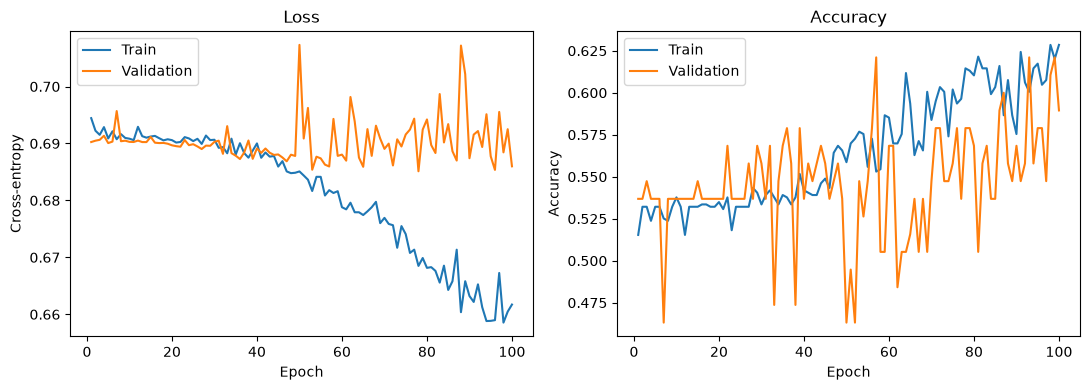

In [25]:
epochs = range(1, len(history["train_loss"]) + 1)
figure, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["validation_loss"], label="Validation")
axes[0].set(title="Loss", xlabel="Epoch", ylabel="Cross-entropy")
axes[0].legend()

axes[1].plot(epochs, history["train_accuracy"], label="Train")
axes[1].plot(epochs, history["validation_accuracy"], label="Validation")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Evaluate the Best Checkpoint

The held-out test set is evaluated only after validation-based model selection is complete.

In [26]:
checkpoint = load_checkpoint(CHECKPOINT_PATH, model, device=device)
test_metrics = evaluate(model, test_loader, criterion, device)

print(f"Best epoch: {checkpoint['epoch']}")
print(f"Test loss: {test_metrics['loss']:.4f}")
print(f"Test accuracy: {test_metrics['accuracy']:.3f}")

Best epoch: 78
Test loss: 0.6636
Test accuracy: 0.600
